In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print('All libraries imported successfully!')

All libraries imported successfully!


In [2]:
df = pd.read_csv(r'C:\Users\Gohar\Desktop\DASS_Complete.csv')

# Fix FALSE in Anxiety
df['Anxiety Severity'] = df['Anxiety Severity'].replace('FALSE', 'Normal')

print('Dataset Shape:', df.shape)
print('\nDepression classes:', df['Depression Severity'].unique())
print('Anxiety classes   :', df['Anxiety Severity'].unique())
print('Stress classes    :', df['Stress Severity'].unique())
df.head()

Dataset Shape: (39775, 49)

Depression classes: ['Extremely Severe' 'Severe' 'Moderate']
Anxiety classes   : ['Extremely Severe' 'Severe' 'Moderate' 'Normal']
Stress classes    : ['Extremely Severe' 'Severe' 'Moderate' 'Normal' 'Mild']


,ID,Q1 (S),Q2 (A),Q3 (D),Q4 (A),Q5 (D),Q6 (S),Q7 (A),Q8 (S),Q9 (A),...,Q39 (S),Q40 (A),Q41 (A),Q42 (D),Depression Score,Depression Severity,Anxiety Score,Anxiety Severity,Stress Score,Stress Severity
0,1,4,4,2,4,4,4,4,4,2,...,4,3,4,4,41,Extremely Severe,48,Extremely Severe,54,Extremely Severe
1,2,4,1,2,3,4,4,3,4,3,...,2,1,2,2,38,Extremely Severe,31,Extremely Severe,41,Extremely Severe
2,3,3,1,4,1,4,3,1,3,2,...,2,2,1,4,53,Extremely Severe,26,Extremely Severe,31,Severe
3,4,2,3,2,1,3,3,4,2,3,...,3,4,4,2,30,Extremely Severe,31,Extremely Severe,30,Severe
4,5,2,2,3,4,4,2,4,4,4,...,3,4,4,3,46,Extremely Severe,54,Extremely Severe,43,Extremely Severe


In [3]:
stress_cols = [
    'Q1 (S)', 'Q6 (S)', 'Q8 (S)', 'Q11 (S)', 'Q12 (S)', 'Q14 (S)',
    'Q18 (S)', 'Q22 (S)', 'Q27 (S)', 'Q29 (S)', 'Q32 (S)', 'Q33 (S)',
    'Q35 (S)', 'Q39 (S)'
]

anxiety_cols = [
    'Q2 (A)', 'Q4 (A)', 'Q7 (A)', 'Q9 (A)', 'Q15 (A)', 'Q19 (A)',
    'Q20 (A)', 'Q23 (A)', 'Q25 (A)', 'Q28 (A)', 'Q30 (A)', 'Q36 (A)',
    'Q40 (A)', 'Q41 (A)'
]

depression_cols = [
    'Q3 (D)', 'Q5 (D)', 'Q10 (D)', 'Q13 (D)', 'Q16 (D)', 'Q17 (D)',
    'Q21 (D)', 'Q24 (D)', 'Q26 (D)', 'Q31 (D)', 'Q34 (D)', 'Q37 (D)',
    'Q38 (D)', 'Q42 (D)'
]

print('Stress    features:', len(stress_cols))
print('Anxiety   features:', len(anxiety_cols))
print('Depression features:', len(depression_cols))

Stress    features: 14
Anxiety   features: 14
Depression features: 14


In [4]:
def prepare_data(feature_cols, target_col):
    """Label encode target and split into train/test."""
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
    )
    return X_train, X_test, y_train, y_test, le


def train_evaluate(model, X_tr, X_te, y_tr, y_te, le, model_name, round_label, cmap='Blues'):
    """Train, evaluate, print report, plot confusion matrix."""
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    print('=' * 55)
    print(f'  {model_name}  |  {round_label}')
    print('=' * 55)
    print(f'  Accuracy : {acc*100:.2f}%')
    print('-' * 55)
    print(classification_report(y_te, y_pred, target_names=le.classes_))

    cm   = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    fig, ax = plt.subplots(figsize=(8, 5))
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    ax.set_title(f'{model_name} | {round_label} | Acc: {acc*100:.2f}%',
                 fontsize=12, fontweight='bold')
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

    return acc, model.feature_importances_


def plot_feature_importance(importances, feature_names, title, color='steelblue'):
    """Plot feature importance and return sorted feature list."""
    feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=False).reset_index(drop=True)

    plt.figure(figsize=(10, 5))
    plt.barh(feat_df['Feature'][::-1], feat_df['Importance'][::-1],
             color=color, edgecolor='black')
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

    return feat_df['Feature'].tolist()


print('Helper functions ready!')

Helper functions ready!


  XGBoost (Stress)  |  Round 1 — All 14 Questions
  Accuracy : 96.15%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      0.99      0.99      4373
            Mild       0.96      0.90      0.93       385
        Moderate       0.92      0.93      0.93      1225
          Normal       1.00      1.00      1.00        62
          Severe       0.93      0.94      0.93      1910

        accuracy                           0.96      7955
       macro avg       0.96      0.95      0.96      7955
    weighted avg       0.96      0.96      0.96      7955



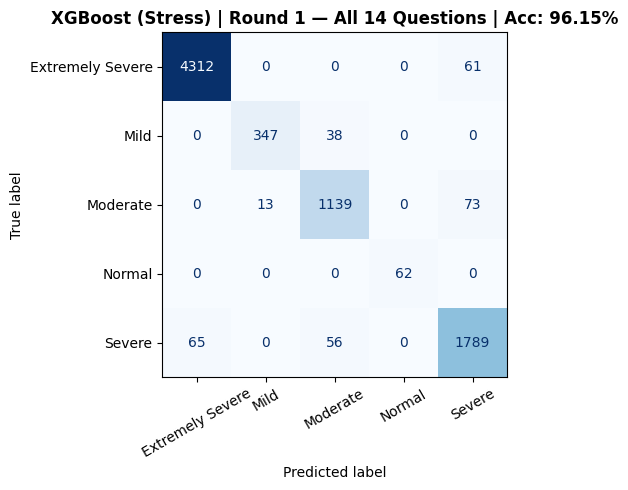

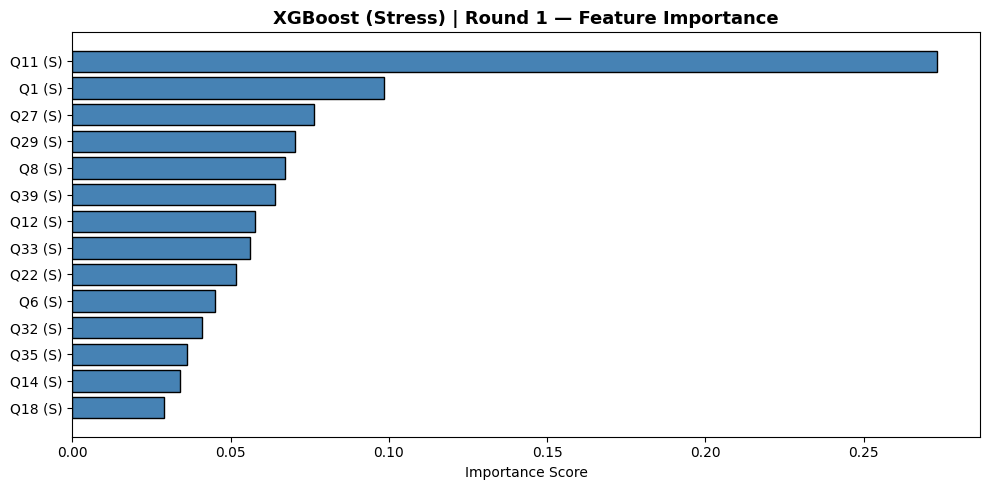

Top 8: ['Q11 (S)', 'Q1 (S)', 'Q27 (S)', 'Q29 (S)', 'Q8 (S)', 'Q39 (S)', 'Q12 (S)', 'Q33 (S)']
Top 3: ['Q11 (S)', 'Q1 (S)', 'Q27 (S)']


In [5]:
X_train_s, X_test_s, y_train_s, y_test_s, le_s = prepare_data(stress_cols, 'Stress Severity')

xgb_s = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                      eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_s_r1, imp_s = train_evaluate(
    xgb_s, X_train_s, X_test_s, y_train_s, y_test_s, le_s,
    model_name='XGBoost (Stress)', round_label='Round 1 — All 14 Questions', cmap='Blues'
)

s_sorted = plot_feature_importance(
    imp_s, stress_cols, 'XGBoost (Stress) | Round 1 — Feature Importance', color='steelblue'
)
s_top8 = s_sorted[:8]
s_top3 = s_sorted[:3]

print('Top 8:', s_top8)
print('Top 3:', s_top3)

  XGBoost (Stress)  |  Round 2 — Top 8 Questions
  Accuracy : 85.32%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.94      0.94      0.94      4373
            Mild       0.65      0.76      0.70       385
        Moderate       0.77      0.76      0.76      1225
          Normal       0.00      0.00      0.00        62
          Severe       0.76      0.77      0.76      1910

        accuracy                           0.85      7955
       macro avg       0.62      0.64      0.63      7955
    weighted avg       0.85      0.85      0.85      7955



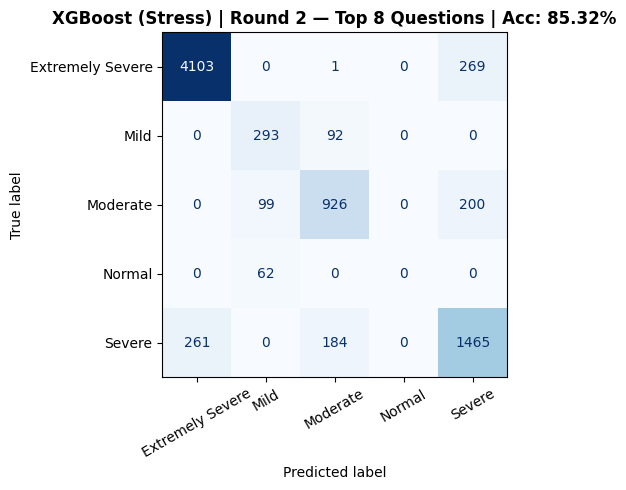

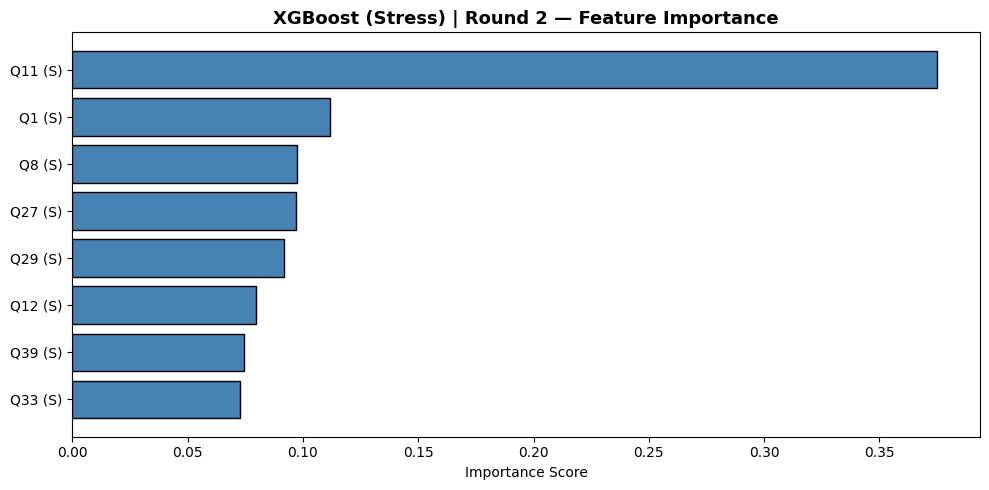

Round 1 Accuracy : 96.15%
Round 2 Accuracy : 85.32%


In [6]:
xgb_s2 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_s_r2, imp_s2 = train_evaluate(
    xgb_s2, X_train_s[s_top8], X_test_s[s_top8], y_train_s, y_test_s, le_s,
    model_name='XGBoost (Stress)', round_label='Round 2 — Top 8 Questions', cmap='Blues'
)

plot_feature_importance(imp_s2, s_top8, 'XGBoost (Stress) | Round 2 — Feature Importance', color='steelblue')

print(f'Round 1 Accuracy : {acc_s_r1*100:.2f}%')
print(f'Round 2 Accuracy : {acc_s_r2*100:.2f}%')

  XGBoost (Stress)  |  Round 3 — Top 3 Questions
  Accuracy : 73.85%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.87      0.90      0.88      4373
            Mild       0.48      0.57      0.52       385
        Moderate       0.58      0.55      0.56      1225
          Normal       0.00      0.00      0.00        62
          Severe       0.58      0.54      0.56      1910

        accuracy                           0.74      7955
       macro avg       0.50      0.51      0.51      7955
    weighted avg       0.73      0.74      0.73      7955



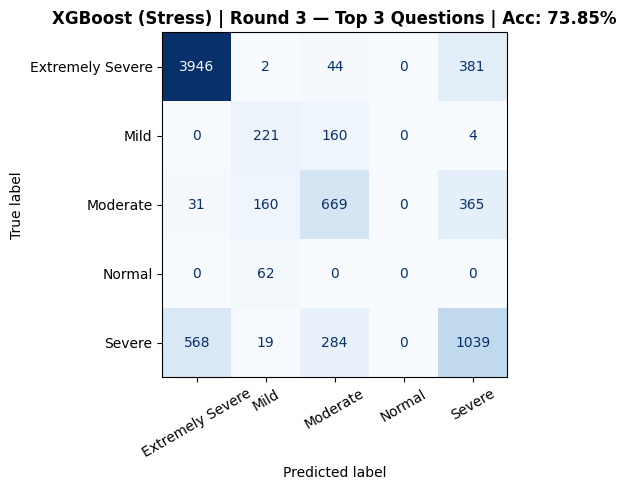

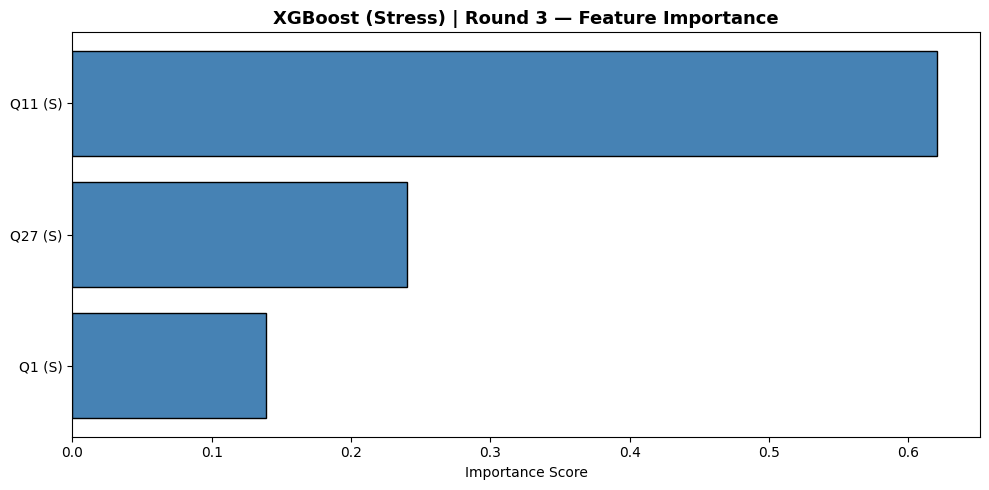

   STRESS (XGBoost) — ROUNDS SUMMARY
  Round 1 (14 Questions) : 96.15%
  Round 2 (Top 8)        : 85.32%
  Round 3 (Top 3)        : 73.85%


In [7]:
xgb_s3 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_s_r3, imp_s3 = train_evaluate(
    xgb_s3, X_train_s[s_top3], X_test_s[s_top3], y_train_s, y_test_s, le_s,
    model_name='XGBoost (Stress)', round_label='Round 3 — Top 3 Questions', cmap='Blues'
)

plot_feature_importance(imp_s3, s_top3, 'XGBoost (Stress) | Round 3 — Feature Importance', color='steelblue')

print('=' * 45)
print('   STRESS (XGBoost) — ROUNDS SUMMARY')
print('=' * 45)
print(f'  Round 1 (14 Questions) : {acc_s_r1*100:.2f}%')
print(f'  Round 2 (Top 8)        : {acc_s_r2*100:.2f}%')
print(f'  Round 3 (Top 3)        : {acc_s_r3*100:.2f}%')

  XGBoost (Anxiety)  |  Round 1 — All 14 Questions
  Accuracy : 98.92%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      1.00      1.00      6577
        Moderate       0.98      1.00      0.99       183
          Normal       0.96      0.92      0.94       191
          Severe       0.97      0.95      0.96      1004

        accuracy                           0.99      7955
       macro avg       0.98      0.97      0.97      7955
    weighted avg       0.99      0.99      0.99      7955



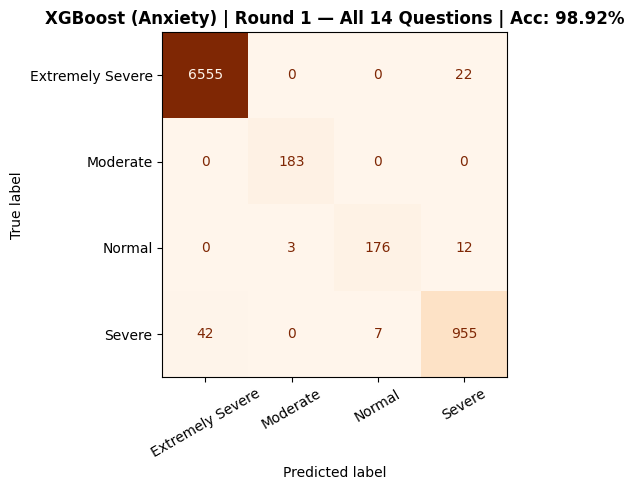

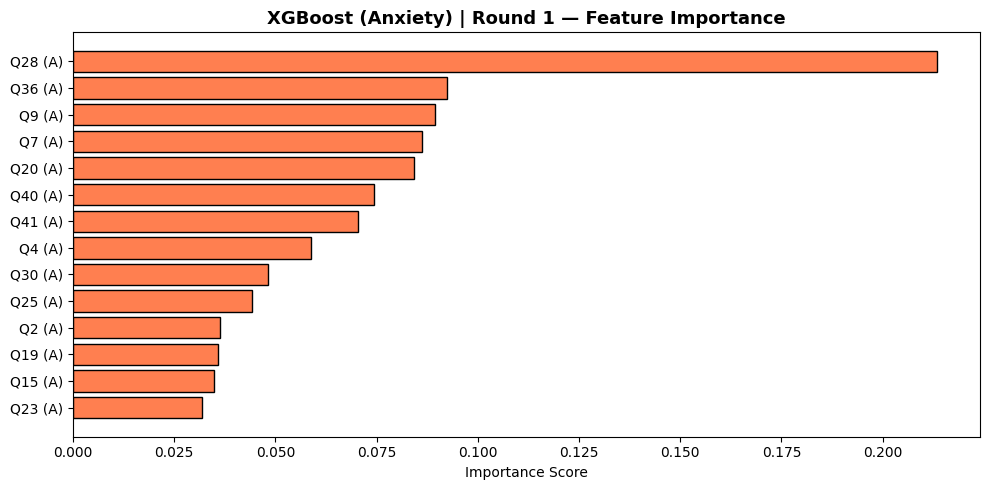

Top 8: ['Q28 (A)', 'Q36 (A)', 'Q9 (A)', 'Q7 (A)', 'Q20 (A)', 'Q40 (A)', 'Q41 (A)', 'Q4 (A)']
Top 3: ['Q28 (A)', 'Q36 (A)', 'Q9 (A)']


In [8]:
X_train_a, X_test_a, y_train_a, y_test_a, le_a = prepare_data(anxiety_cols, 'Anxiety Severity')

xgb_a = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                      eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_a_r1, imp_a = train_evaluate(
    xgb_a, X_train_a, X_test_a, y_train_a, y_test_a, le_a,
    model_name='XGBoost (Anxiety)', round_label='Round 1 — All 14 Questions', cmap='Oranges'
)

a_sorted = plot_feature_importance(
    imp_a, anxiety_cols, 'XGBoost (Anxiety) | Round 1 — Feature Importance', color='coral'
)
a_top8 = a_sorted[:8]
a_top3 = a_sorted[:3]

print('Top 8:', a_top8)
print('Top 3:', a_top3)

  XGBoost (Anxiety)  |  Round 2 — Top 8 Questions
  Accuracy : 91.54%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.97      0.97      0.97      6577
        Moderate       0.50      1.00      0.66       183
          Normal       0.00      0.00      0.00       191
          Severe       0.70      0.74      0.72      1004

        accuracy                           0.92      7955
       macro avg       0.54      0.68      0.59      7955
    weighted avg       0.90      0.92      0.91      7955



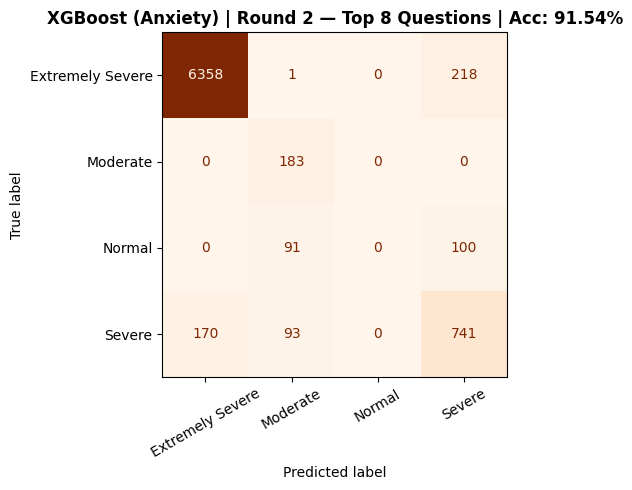

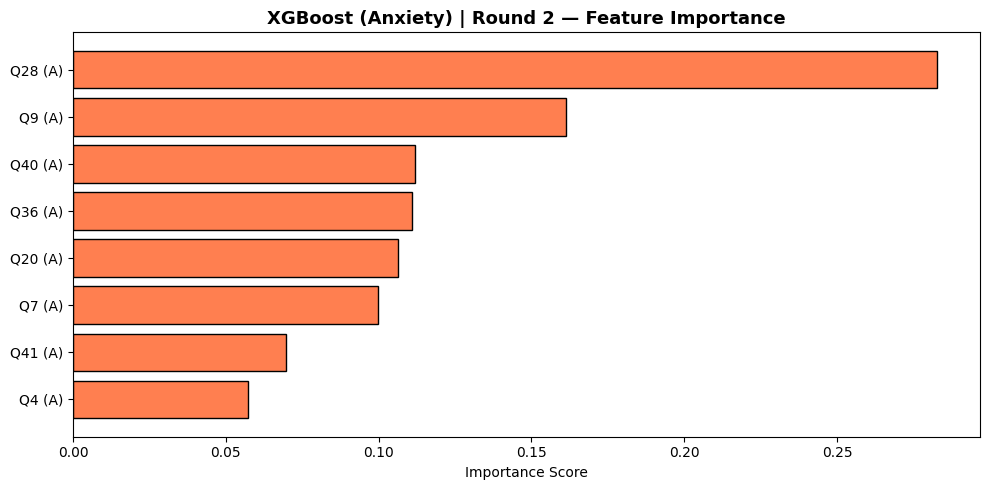

Round 1 Accuracy : 98.92%
Round 2 Accuracy : 91.54%


In [9]:
xgb_a2 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_a_r2, imp_a2 = train_evaluate(
    xgb_a2, X_train_a[a_top8], X_test_a[a_top8], y_train_a, y_test_a, le_a,
    model_name='XGBoost (Anxiety)', round_label='Round 2 — Top 8 Questions', cmap='Oranges'
)

plot_feature_importance(imp_a2, a_top8, 'XGBoost (Anxiety) | Round 2 — Feature Importance', color='coral')

print(f'Round 1 Accuracy : {acc_a_r1*100:.2f}%')
print(f'Round 2 Accuracy : {acc_a_r2*100:.2f}%')

  XGBoost (Anxiety)  |  Round 3 — Top 3 Questions
  Accuracy : 85.86%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.94      0.94      0.94      6577
        Moderate       0.00      0.00      0.00       183
          Normal       0.00      0.00      0.00       191
          Severe       0.46      0.63      0.53      1004

        accuracy                           0.86      7955
       macro avg       0.35      0.39      0.37      7955
    weighted avg       0.84      0.86      0.85      7955



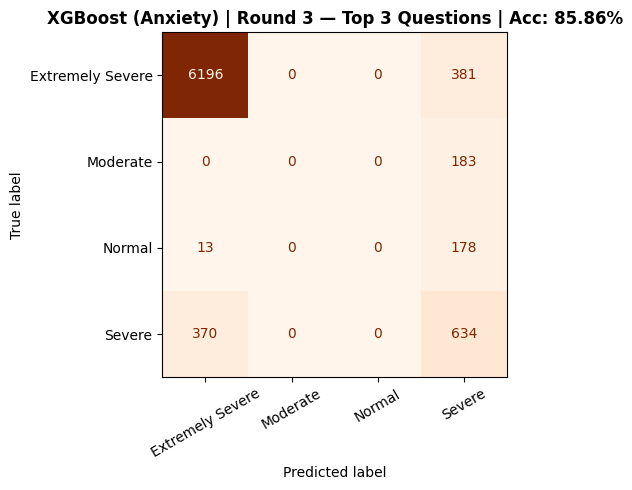

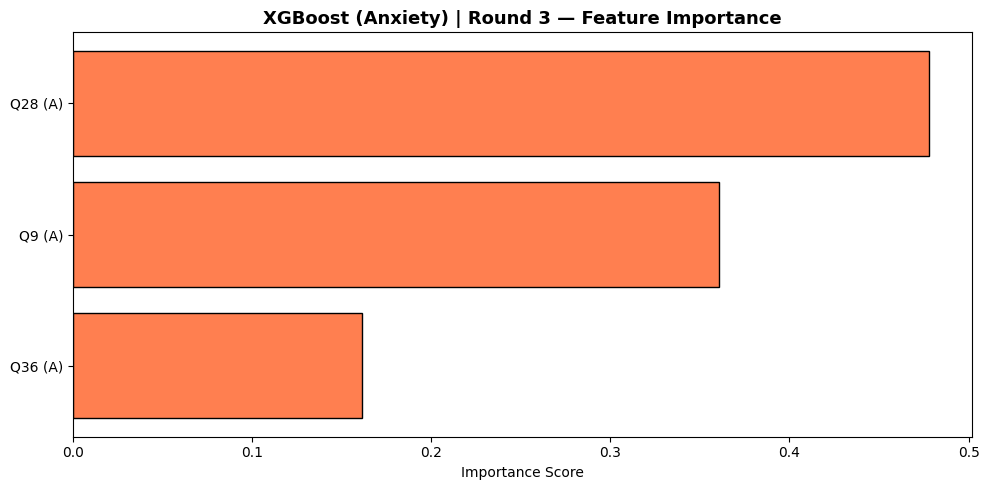

   ANXIETY (XGBoost) — ROUNDS SUMMARY
  Round 1 (14 Questions) : 98.92%
  Round 2 (Top 8)        : 91.54%
  Round 3 (Top 3)        : 85.86%


In [10]:
xgb_a3 = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6,
                       eval_metric='mlogloss', random_state=42, n_jobs=-1)

acc_a_r3, imp_a3 = train_evaluate(
    xgb_a3, X_train_a[a_top3], X_test_a[a_top3], y_train_a, y_test_a, le_a,
    model_name='XGBoost (Anxiety)', round_label='Round 3 — Top 3 Questions', cmap='Oranges'
)

plot_feature_importance(imp_a3, a_top3, 'XGBoost (Anxiety) | Round 3 — Feature Importance', color='coral')

print('=' * 45)
print('   ANXIETY (XGBoost) — ROUNDS SUMMARY')
print('=' * 45)
print(f'  Round 1 (14 Questions) : {acc_a_r1*100:.2f}%')
print(f'  Round 2 (Top 8)        : {acc_a_r2*100:.2f}%')
print(f'  Round 3 (Top 3)        : {acc_a_r3*100:.2f}%')

  Random Forest (Depression)  |  Round 1 — All 14 Questions
  Accuracy : 97.32%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.99      0.99      0.99      5426
        Moderate       0.96      0.98      0.97      1215
          Severe       0.93      0.90      0.92      1314

        accuracy                           0.97      7955
       macro avg       0.96      0.96      0.96      7955
    weighted avg       0.97      0.97      0.97      7955



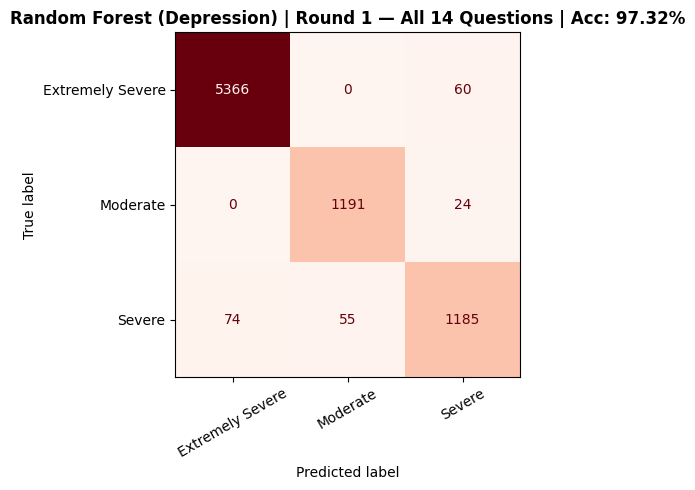

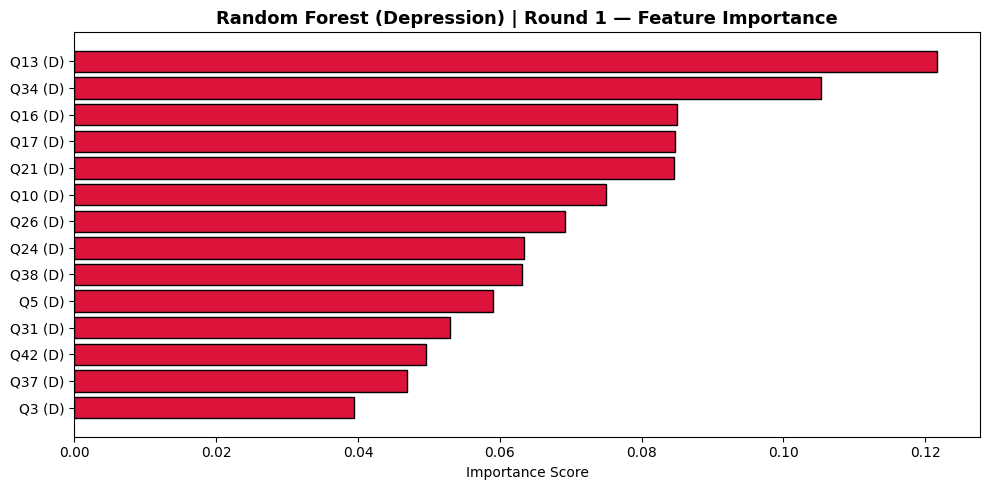

Top 8: ['Q13 (D)', 'Q34 (D)', 'Q16 (D)', 'Q17 (D)', 'Q21 (D)', 'Q10 (D)', 'Q26 (D)', 'Q24 (D)']
Top 3: ['Q13 (D)', 'Q34 (D)', 'Q16 (D)']


In [11]:
X_train_d, X_test_d, y_train_d, y_test_d, le_d = prepare_data(depression_cols, 'Depression Severity')

rf_d = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=42, n_jobs=-1)

acc_d_r1, imp_d = train_evaluate(
    rf_d, X_train_d, X_test_d, y_train_d, y_test_d, le_d,
    model_name='Random Forest (Depression)', round_label='Round 1 — All 14 Questions', cmap='Reds'
)

d_sorted = plot_feature_importance(
    imp_d, depression_cols, 'Random Forest (Depression) | Round 1 — Feature Importance', color='crimson'
)
d_top8 = d_sorted[:8]
d_top3 = d_sorted[:3]

print('Top 8:', d_top8)
print('Top 3:', d_top3)

  Random Forest (Depression)  |  Round 2 — Top 8 Questions
  Accuracy : 90.62%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.97      0.94      0.96      5426
        Moderate       0.87      0.90      0.88      1215
          Severe       0.70      0.77      0.73      1314

        accuracy                           0.91      7955
       macro avg       0.85      0.87      0.86      7955
    weighted avg       0.91      0.91      0.91      7955



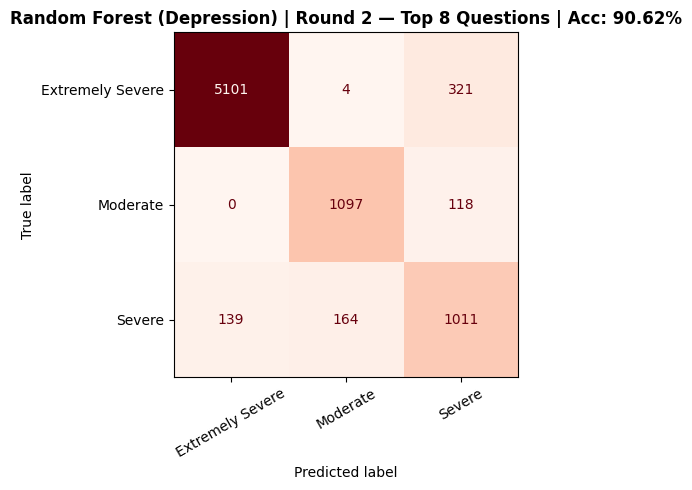

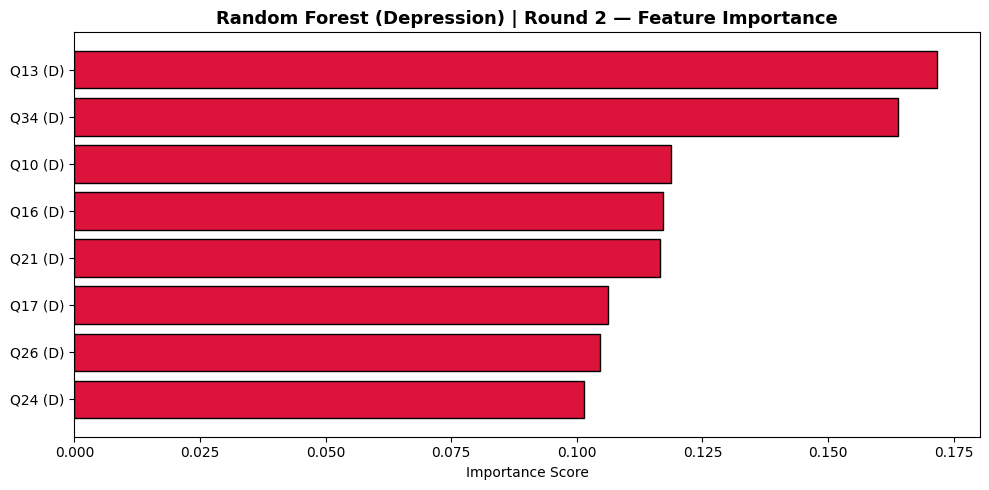

Round 1 Accuracy : 97.32%
Round 2 Accuracy : 90.62%


In [12]:
rf_d2 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)

acc_d_r2, imp_d2 = train_evaluate(
    rf_d2, X_train_d[d_top8], X_test_d[d_top8], y_train_d, y_test_d, le_d,
    model_name='Random Forest (Depression)', round_label='Round 2 — Top 8 Questions', cmap='Reds'
)

plot_feature_importance(imp_d2, d_top8, 'Random Forest (Depression) | Round 2 — Feature Importance', color='crimson')

print(f'Round 1 Accuracy : {acc_d_r1*100:.2f}%')
print(f'Round 2 Accuracy : {acc_d_r2*100:.2f}%')

  Random Forest (Depression)  |  Round 3 — Top 3 Questions
  Accuracy : 83.24%
-------------------------------------------------------
                  precision    recall  f1-score   support

Extremely Severe       0.97      0.86      0.91      5426
        Moderate       0.80      0.82      0.81      1215
          Severe       0.50      0.73      0.60      1314

        accuracy                           0.83      7955
       macro avg       0.76      0.80      0.77      7955
    weighted avg       0.87      0.83      0.84      7955



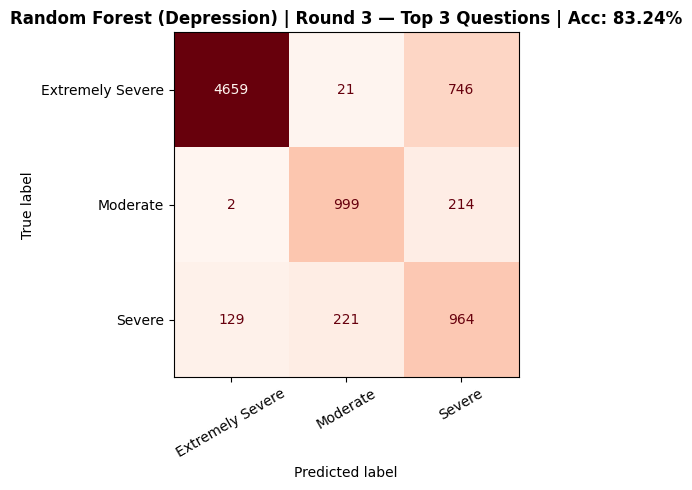

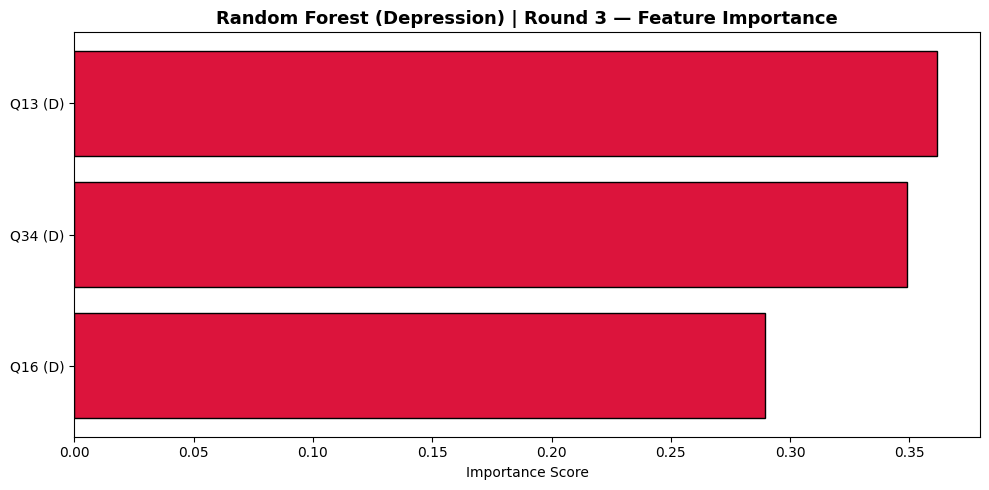

   DEPRESSION (Random Forest) — ROUNDS SUMMARY
  Round 1 (14 Questions) : 97.32%
  Round 2 (Top 8)        : 90.62%
  Round 3 (Top 3)        : 83.24%


In [13]:
rf_d3 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)

acc_d_r3, imp_d3 = train_evaluate(
    rf_d3, X_train_d[d_top3], X_test_d[d_top3], y_train_d, y_test_d, le_d,
    model_name='Random Forest (Depression)', round_label='Round 3 — Top 3 Questions', cmap='Reds'
)

plot_feature_importance(imp_d3, d_top3, 'Random Forest (Depression) | Round 3 — Feature Importance', color='crimson')

print('=' * 45)
print('   DEPRESSION (Random Forest) — ROUNDS SUMMARY')
print('=' * 45)
print(f'  Round 1 (14 Questions) : {acc_d_r1*100:.2f}%')
print(f'  Round 2 (Top 8)        : {acc_d_r2*100:.2f}%')
print(f'  Round 3 (Top 3)        : {acc_d_r3*100:.2f}%')

In [14]:
summary = {
    'Category'   : ['Stress', 'Stress', 'Stress',
                    'Anxiety', 'Anxiety', 'Anxiety',
                    'Depression', 'Depression', 'Depression'],
    'Hero Model' : ['XGBoost'] * 3 + ['XGBoost'] * 3 + ['Random Forest'] * 3,
    'Round'      : ['Round 1 (14Q)', 'Round 2 (Top 8)', 'Round 3 (Top 3)'] * 3,
    'Accuracy (%)': [
        round(acc_s_r1*100, 2), round(acc_s_r2*100, 2), round(acc_s_r3*100, 2),
        round(acc_a_r1*100, 2), round(acc_a_r2*100, 2), round(acc_a_r3*100, 2),
        round(acc_d_r1*100, 2), round(acc_d_r2*100, 2), round(acc_d_r3*100, 2)
    ]
}

summary_df = pd.DataFrame(summary)

print('=' * 65)
print('   HERO MODELS — CROSS CATEGORY COMPARISON')
print('=' * 65)
print(summary_df.to_string(index=False))

   HERO MODELS — CROSS CATEGORY COMPARISON
  Category    Hero Model           Round  Accuracy (%)
    Stress       XGBoost   Round 1 (14Q)         96.15
    Stress       XGBoost Round 2 (Top 8)         85.32
    Stress       XGBoost Round 3 (Top 3)         73.85
   Anxiety       XGBoost   Round 1 (14Q)         98.92
   Anxiety       XGBoost Round 2 (Top 8)         91.54
   Anxiety       XGBoost Round 3 (Top 3)         85.86
Depression Random Forest   Round 1 (14Q)         97.32
Depression Random Forest Round 2 (Top 8)         90.62
Depression Random Forest Round 3 (Top 3)         83.24


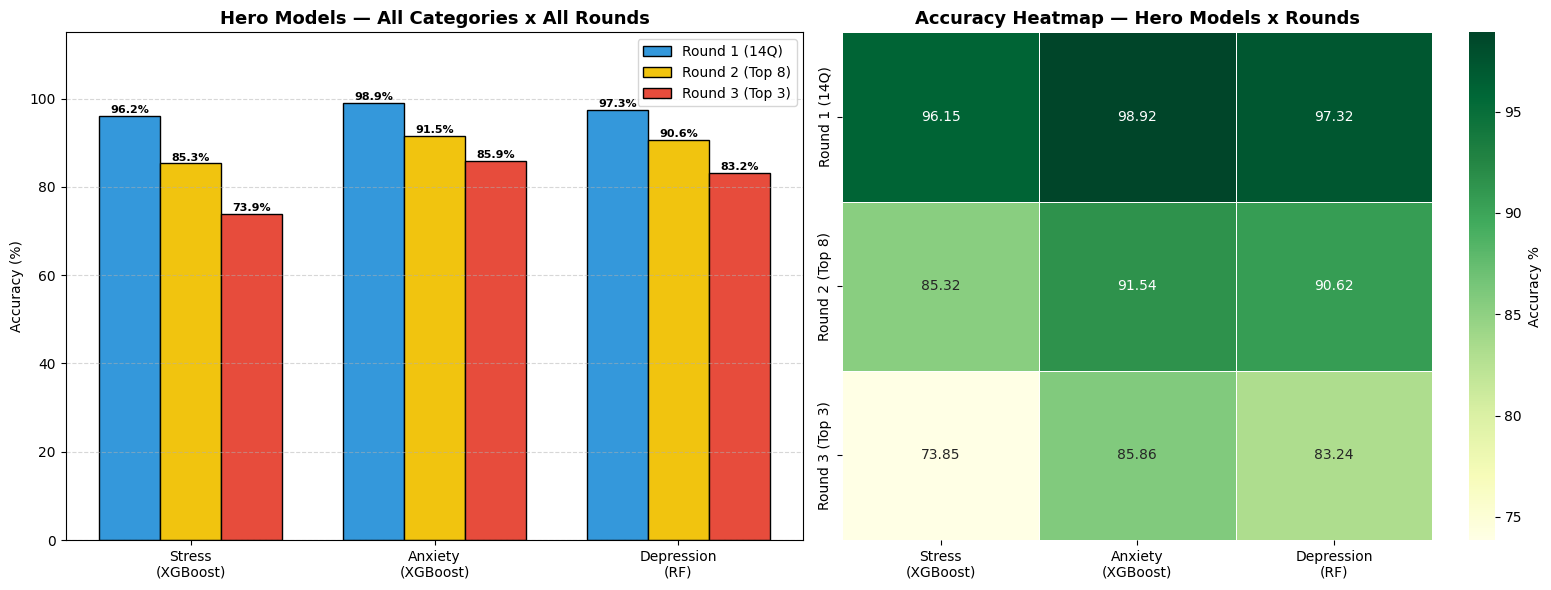

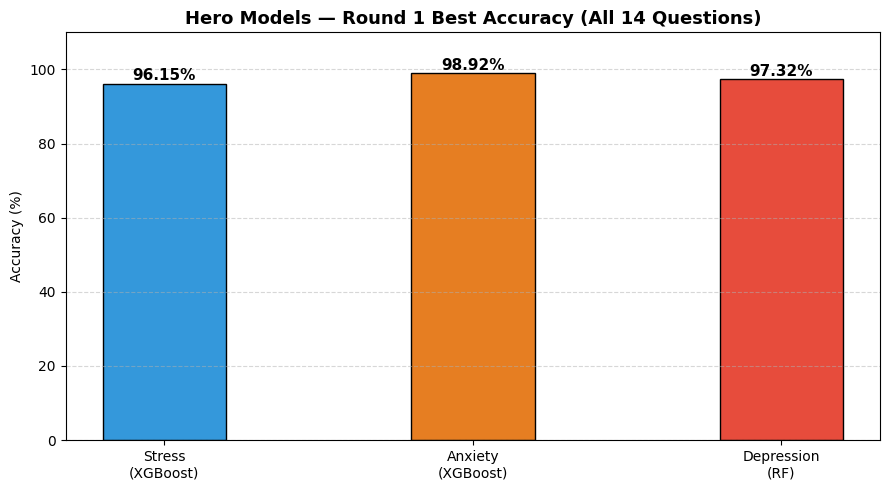

In [15]:
categories = ['Stress\n(XGBoost)', 'Anxiety\n(XGBoost)', 'Depression\n(RF)']
r1 = [acc_s_r1*100, acc_a_r1*100, acc_d_r1*100]
r2 = [acc_s_r2*100, acc_a_r2*100, acc_d_r2*100]
r3 = [acc_s_r3*100, acc_a_r3*100, acc_d_r3*100]

x     = np.arange(len(categories))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Grouped Bar Chart ──
b1 = axes[0].bar(x - width, r1, width, label='Round 1 (14Q)',   color='#3498db', edgecolor='black')
b2 = axes[0].bar(x,         r2, width, label='Round 2 (Top 8)', color='#f1c40f', edgecolor='black')
b3 = axes[0].bar(x + width, r3, width, label='Round 3 (Top 3)', color='#e74c3c', edgecolor='black')

for bars in [b1, b2, b3]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{bar.get_height():.1f}%', ha='center', va='bottom',
                     fontsize=8, fontweight='bold')

axes[0].set_title('Hero Models — All Categories x All Rounds', fontsize=13, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim(0, 115)
axes[0].legend()
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# ── Heatmap ──
heat_data = np.array([r1, r2, r3])
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlGn',
            xticklabels=['Stress\n(XGBoost)', 'Anxiety\n(XGBoost)', 'Depression\n(RF)'],
            yticklabels=['Round 1 (14Q)', 'Round 2 (Top 8)', 'Round 3 (Top 3)'],
            ax=axes[1], linewidths=0.5, cbar_kws={'label': 'Accuracy %'})
axes[1].set_title('Accuracy Heatmap — Hero Models x Rounds', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Round 1 Bar — Best per Category ──
plt.figure(figsize=(9, 5))
bar_colors = ['#3498db', '#e67e22', '#e74c3c']
bars = plt.bar(['Stress\n(XGBoost)', 'Anxiety\n(XGBoost)', 'Depression\n(RF)'],
               r1, color=bar_colors, edgecolor='black', width=0.4)
for bar, val in zip(bars, r1):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{val:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.title('Hero Models — Round 1 Best Accuracy (All 14 Questions)', fontsize=13, fontweight='bold')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()